In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Pre-processing data: DiCOM - HDF5 
- Some docs:
https://pydicom.github.io/pydicom/stable/guides/user/working_with_pixel_data.html

DiCOM is a data format common in medeical imaging. It is likely to also persist in domains that use popular medical imaging technologies (eg., CT scans, MRI, etc.) for non-medical applications. Like HDF5, DiCOM is essentially a container that bundles one or more images (presumably, a stack of related images), some metadata, and perhaps some analytical overlays. Software APIs, for example `pydicom`, package together code to interpret the various date elements, implement standard compression algorightms, etc.

DiCOM represents a big step forward from conventions that preceded it, in that it bundles together relate images and pertient meta-data. This is great for analysis of a single imaging event, or to compare multiple time separated imaging events (eg, to show change in time). For aggregate analysis however, for example training a machine learning (ML) model on thousands or even millions of images, it may (will almost certainly...) be advantageous to further bundle image data into DiCOM or HDF5 files, in order to reduce IO latency.

Doing this -- bundling images into a single indexed file, rather than reading from many small(er) files, can speed up some ML (or other image rendering or analytical) workflows many fole -- often improving performance between 10x and 100x. Given the scarcity and cost of GPU computing, this can mean the difference between the feasability or non-feasibility of a project, or at verylest can  *_significantly_* reduce to the cost of computation. Consider that, even in cases where the performance _gain_ is minimal, much of the coputation time is shifted to inexpensive CPU machines.


In [2]:
import numpy
import pylab as plt
import scipy
import math
#import PIL
import os
import time
import h5py
import glob
#
import sys
import os
#
if not '/Users/myoder96/anaconda3/envs/dicom/lib/python3.13/site-packages' in sys.path:
    sys.path += ['/Users/myoder96/anaconda3/envs/dicom/lib/python3.13/site-packages']
import gdcm
#import Pillow
import PIL
import pylibjpeg

import pydicom

## Built in examples:
- pydicom had some built in examples. These might be useful to demonstrate consolitation methods.
- Most of the example files are single images, or maybe a short series of images (eg, set of images for a single imaging event or patient)
- There are examples of RGB data, eg shape=(100,100,3).
- Note that a stack of these images, for ML, would be like shape=(N,100,100,3)
- "Examples" also include some overlay examples and other images without `pixel_data` (and so also no `pixel_array`) or without meta data.


In [198]:
# Write a simple images viewer:
#
def view_images(data_file, dataset=None, n_cols=4, img_size=2., palette=None, cmap=None):
    #
    ext = os.path.splitext(data_file)[1]
    #
    #print('*** ext: ', ext)
    if ext.lower().endswith('h5'):
        with h5py.File(data_file, 'r') as fin:
            data = fin[dataset][:]
    else:
        with pydicom.dcmread(data_file) as fin:
            data = fin.pixel_array[:]
    #
    #
    Nz, Ny, Nx = data.shape
    n_rows = int(numpy.ceil(Nz/n_cols))
    #
    while (n_cols * n_rows) < N:
        n_rows += 1
    #
    ax_side = img_size
    fg = plt.figure(figsize=(ax_side*n_cols, ax_side*n_rows))
    fg.clear()
    #
    for k,X in enumerate(data):
        # if k>N:
        #     break
        #
        #print(f'** ary[{k}]')
        ax = fg.add_subplot(n_rows, n_cols, k+1)
        if not palette is None:
            #print('*** executing with pallette...')
            ax.imshow(pydicom.pixels.apply_color_lut(X, palette=palette), cmap=cmap)
        else:
            #print(f'** executing as if None... [{pallette}], { (pallette is None) }')
            ax.imshow(X, cmap=cmap)
        #
        ax.set_title(f'Image: {k}')
        #
    plt.show()    

    

# Let's look at one of those files and see what the images look like:
# test_file = '0003.DCM'
# view_images(os.path.join(dicom_data_path, test_file), palette=None, cmap=plt.cm.afmhot)


## PyDicom includes some built in examples

In [196]:
#ls -lh dicom_data
# Also see built in examples:
examples_path = pydicom.examples.get_path("mr")  # The path to the examples.mr dataset
print(f'** examples_path: {examples_path}')
#
# and let's have a look at the array shapes, to see if they might be good examples for ML workflows
#  or other consolidation applications:
for k,fl in enumerate(glob.glob(f'{os.path.split(examples_path)[0]}/*.dcm')):
    with pydicom.dcmread(fl, force=True) as dcf:
        #print(f'** {fl}') 
        #
        try:
            ary = dcf.pixel_array
            print(f'** fl[{k}] {os.path.split(fl)[1]}: {numpy.shape(ary)}')
        except:
            ary = numpy.empty(shape=(0,0,0))
            print('** broken. skipping.')
        #
        
    #
    

** examples_path: /Users/myoder96/anaconda3/envs/dicom/lib/python3.13/site-packages/pydicom/data/test_files/MR_small.dcm
** broken. skipping.
** broken. skipping.
** broken. skipping.
** fl[3] MR_small_bigendian.dcm: 42
** broken. skipping.
** fl[5] SC_rgb_jls_lossy_line.dcm: 42
** fl[6] SC_rgb_dcmtk_+eb+cy+s2.dcm: 42
** broken. skipping.
** fl[8] MR_small_padded.dcm: 42
** fl[9] SC_rgb_dcmtk_+eb+cr.dcm: 42
** broken. skipping.
** fl[11] MR_small_implicit.dcm: 42
** fl[12] SC_rgb_jpeg_dcmd.dcm: 42
** fl[13] MR_small_RLE.dcm: 42
** fl[14] MR_small_expb.dcm: 42
** fl[15] rtdose_rle_1frame.dcm: 42
** fl[16] examples_palette.dcm: 42
** fl[17] JPEGLSNearLossless_16.dcm: 42
** broken. skipping.
** broken. skipping.
** fl[20] SC_rgb_dcmtk_+eb+cy+s4.dcm: 42
** fl[21] SC_rgb_small_odd_big_endian.dcm: 42
** fl[22] examples_ybr_color.dcm: 42
** fl[23] ExplVR_BigEnd.dcm: 42
** fl[24] SC_rgb_rle.dcm: 42
** fl[25] MR_small.dcm: 42
** fl[26] SC_rgb_jpeg.dcm: 42
** fl[27] examples_rgb_color.dcm: 42
**

Invalid number of tiles : 4292730882 x 1 (maximum fixed by jpeg2000 norm is 65535 tiles)
Marker handler function failed to read the marker segment


## Some DCM examples we downloaded

[https://www.rubomedical.com/dicom_files/index.html](https://www.rubomedical.com/dicom_files/index.html)
- Use `pydicom` to open the DCM files
- View dimensions of `pixel_array`
- Meta-data?
- Show some pictures!

Note that this is not _fully_ scripted; you will need to download the data, set up some paths, etc.

In [168]:
dicom_data_path = './dicom_data'
#dicom_files = list(glob.glob(os.path.join(dicom_data_path, '*.DCM')))
dicom_files = [s  for ex in ['dcm', 'DCM'] for s in glob.glob(os.path.join(dicom_data_path, f'*.{ex}'))]
#
for fl in dicom_files:
    print(f'** {fl}')

** ./dicom_data/0004.DCM
** ./dicom_data/0002.DCM
** ./dicom_data/0003.DCM
** ./dicom_data/0015.DCM
** ./dicom_data/MRBRAIN.DCM
** ./dicom_data/0020.DCM
** ./dicom_data/0009.DCM


## Multiple images per `DCM` and array shape
The dimension of `pixel_array` indicates how many images there are, and what are the dimensions of those images. For example, `0004.DCM` includes 17 512 x 512 images; `0002.DCM` includes 96 images, each with x-y dimensions of 512 x 512. For example:

In [200]:
#dc_1 = dicom.dcmread(dicom_files[0])
#
for k, fl in enumerate(dicom_files):
    with pydicom.dcmread(fl) as dcf:
        ary = dcf.pixel_array
        print(f'** shape[k] ({os.path.split(fl)[1]}): {numpy.shape(ary)}')

print(f'** shape: {numpy.shape(ary)}')

** shape[k] (0004.DCM): (17, 512, 512)
** shape[k] (0002.DCM): (96, 512, 512)
** shape[k] (0003.DCM): (17, 512, 512)
** shape[k] (0015.DCM): (1024, 1024)
** shape[k] (MRBRAIN.DCM): (512, 512)
** shape[k] (0020.DCM): (11, 430, 600)
** shape[k] (0009.DCM): (137, 512, 512)
** shape: (137, 512, 512)


Note that these are single layer images. If the data included multi-layer (eg. RGB, etc.) images, we would see an additional dimension. For example, a file containing 17 3-layer RGB images might look slomething like,

`** shape (RGBs.DCM): (17, 512, 512, 3)`

Let's look at some images below:

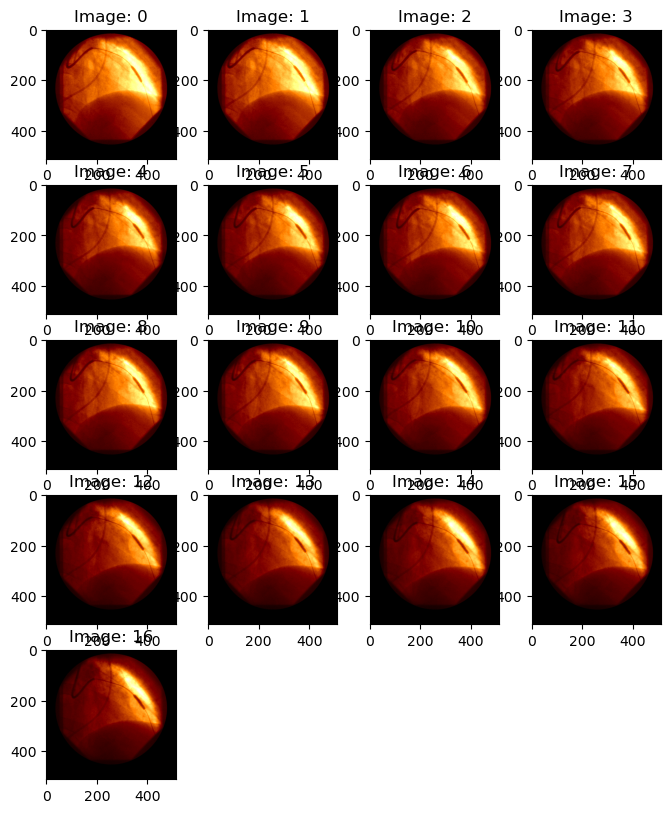

In [199]:
test_file = '0003.DCM'
zz = view_images(os.path.join(dicom_data_path, test_file), palette=None, cmap=plt.cm.afmhot)


## Consolidateing images
If we intend to do some ML, or other analysis, of images from multiple file sources, it will almost certainly be beneficial to consolidate those images into one, or at least very few, files. Speed performance will be optimized by consolidating into as few files as possible (eg, one...); on Stanford Research Computing's Oak platform, individual files should be larger than at least 7MB.

Data can be consolidated into any number of containers, including:
- Text, .csv, etc. (but why would you?)
- DICOM
- HDF5
- Numpy.array -> pickle()
  - This is probably easy to do and fast to load, but generally a bad idea for a number of reasons.
- Some other binary format

Here, we will focus on DICOM and HDF5.

## ML subsets
In this example, we have 4 DCM files that at least have the same image dimensions, so we are goiong to assume (or pretend...) that they are all compatilbe and can be used together for an ML workflow. Files include:
- 0002.DCM: 96  images
- 0003.DCM: 17  images
- 0004.DCM: 17  images
- 0009.DCM: 137 images

We will organize this set to illustrate some salient points of HDF5-foo, in the context of machine learning. To this end, we construct three subsets:
- Training: 0002.DCM
- Testing: 0003.DCM + 0004.DCM
- Inference: 0009.DCM

To better illustreate how to consolidate files, we might add one or more files twice.

First, in HDF5:
    - Create an HDF5 object (File)
    - Create 3 Dataset()s
        - Training
        - Testing
        - Inference
    - Show the images, consolidated into one HDF5.dataset array.
    

In [201]:
working_data_h5 = os.path.join(dicom_data_path, 'working_data.h5')
#
# NOTE: we double up some of the data sets to illustrate appending data sets.
training_data_files  = [os.path.join(dicom_data_path, s) for s in ['0002.DCM', '0002.DCM']]
testing_data_files   = [os.path.join(dicom_data_path, s) for s in ['0003.DCM', '0004.DCM', '0003.DCM']]
inference_data_files = [os.path.join(dicom_data_path, s) for s in ['0009.DCM', '0009.DCM']]
#
# NOTE: having some issues making numpy.append() work well, so getting correct array shape for multiple inputs is
# messy, so do not assume this is the best way to do this part.
#
with h5py.File(working_data_h5, 'w') as h5f:
    #
    # There are lots of good and bad ways to import and write the data. This step -- consolidating, orgainizing,
    # and pre-processing data is not always pretty. Often, it is more important that this process be flexible
    # and transparent than highly optimized, so these steps might not always be your proudest code.
    #
    ########################
    # training data:
    # there are lots of ways to work through the data. This approach makes two passes through the data,
    # so that the array size and shape can be determined in the first pass, then the array can be created
    # to it's full size in one step, which can save memory and time.
    #
    Nz = 0
    for n,fl in enumerate(training_data_files):
        with pydicom.dcmread(fl) as dcf:
            Nz += dcf.pixel_array.shape[0]
            if n == 0:
                # NOTE: you can also use this step to confirm that all the sub-arrays have the same shape.
                ny, nx = dcf.pixel_array.shape[1:]
    # Now, spin through it again and assign data:
    k=0
    h5f.create_dataset('training', (Nz, ny, nx) )
    for fl in training_data_files:
        with pydicom.dcmread(fl) as dcf:
            n_arrays = dcf.pixel_array.shape[0]
            h5f['training'][k:k+n_arrays] = dcf.pixel_array[:]
            k += n_arrays
            #
    #
    ####################
    # This approach uses numpy.append(). numpy.append() appends values to a copy of the
    #  array, which can be expensive in terms of memory write time and also can result in 
    #  memory use spikes.
    #
    # testing:
    data = None
    for fl in testing_data_files:
        with pydicom.dcmread(fl) as dcf:
            if data is None:
                data = dcf.pixel_array[:]
                sh = data.shape
            else:
                # NOTE: Specify the append axis= to preserve the shape. If this is excluded,
                #  numpy.append() will return a shape=(1,) array (ie, numpy.ravel(data) ).
                data = numpy.append(data, dcf.pixel_array, axis=0)
            #
    h5f.create_dataset('testing', data=data)
    #
    ########################
    # inference:
    data = None
    #
    # here's another way to assign data. Also, having trouble with append...
    for fl in inference_data_files:
        with pydicom.dcmread(fl) as dcf:
            if data is None:
                data = dcf.pixel_array[:]
                sh = data.shape
            else:
                data = numpy.append(data, dcf.pixel_array[:], axis=0)
                #data.shape=numpy.array([sh[0] + dcf.pixel_array.shape[0], sh[1:]])
                #
                #pass
            #
    h5f.create_dataset('inference', data=data)
    #
    # create a group out of principle, to show we can (and some other stuff later)
    h5f.create_group('some_group')
    
    
#########
# have a look at what we created:
with h5py.File(working_data_h5, 'r') as h5f:
    print('** ', h5f.keys())
    #
    for ds in h5f.keys():
        #print(f'** {type(h5f[ds])}')
        is_DS = isinstance(h5f[ds], h5py.Dataset)
        print(f'** [{k}] {ds}: {(f"(DS): {h5f[ds].shape}" if is_DS else "(GR)")}')
        #
        # if is_DS:
        #     print(f'** SH: {h5f[ds].shape}')

**  <KeysViewHDF5 ['inference', 'some_group', 'testing', 'training']>
** [192] inference: (DS): (274, 512, 512)
** [192] some_group: (GR)
** [192] testing: (DS): (51, 512, 512)
** [192] training: (DS): (192, 512, 512)


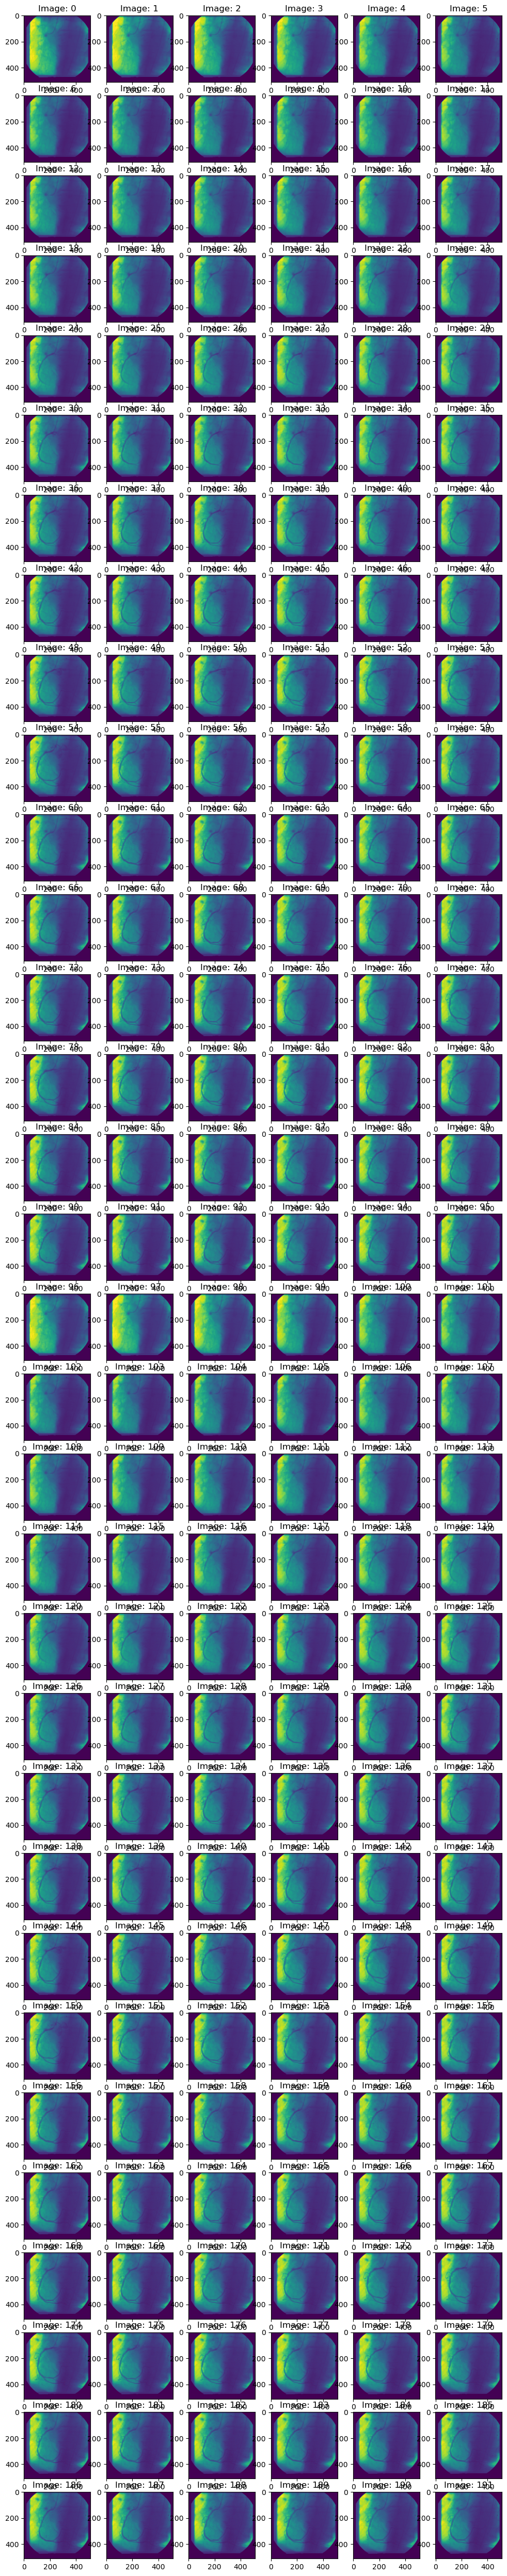

In [118]:
# Plot some images:
view_images('dicom_data/working_data.h5', dataset='training', n_cols=6)

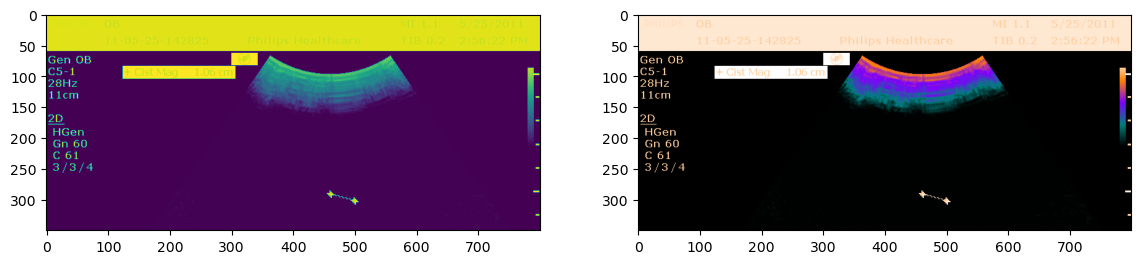

In [105]:
from pydicom import examples
from pydicom.pixels import apply_color_lut

ds = examples.palette_color
arr = ds.pixel_array
# You could also use the corresponding well-known SOP Instance UID
rgb = apply_color_lut(arr, palette='PET')
#
fg = plt.figure(figsize=(14,6))
ax1 = fg.add_subplot(1,2,1)
ax2 = fg.add_subplot(1,2,2)
ax1.imshow(arr)
ax2.imshow(rgb)
plt.show()

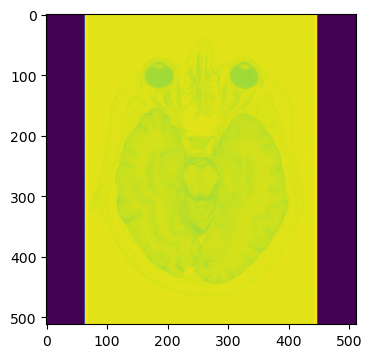

In [14]:
#%pip install plotly
fname = os.path.join(dicom_data_path, 'MRBRAIN.DCM')
with pydicom.dcmread(fname, 'r') as dcf:
    X = dcf.pixel_array
    #
    fg = plt.figure(figsize=(4,5))
    ax = fg.add_subplot(1,1,1)
    ax.imshow(X)
    plt.show()


In [ ]:
print('** ', X)

In [169]:
from pydicom import examples
ds = examples.overlay
elem = ds[0x6000, 0x3000]  # returns a DataElement
print(elem)


(6000,3000) Overlay Data                        OW: Array of 18150 elements


** overlay_shape: (300, 484)


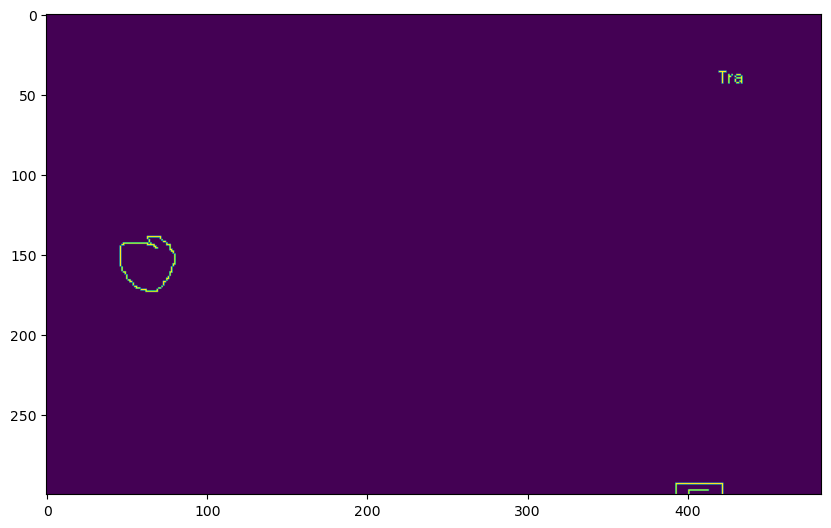

In [177]:
#print('** ', elem.value)

arr_1 = ds.overlay_array(0x6000)
#arr_2 = ds.overlay_array(0x3000)
print(f'** overlay_shape: {arr_1.shape}')

fg = plt.figure(figsize=(10,8))
ax = fg.add_subplot(1,1,1)
#
ax.imshow(arr_1)
plt.show()